In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

### Module 1, Phase 1: The Supervised Learning Framework - Theory

#### 1. What is Supervised Learning?

At its heart, supervised learning is the task of learning a mapping from inputs to outputs based on **labeled examples**. Imagine a teacher providing the "correct answers" (labels) for a set of problems (inputs). The goal is for the student (the algorithm) to learn a general rule that allows them to correctly answer *new*, unseen problems.

Think of it this way: when you were learning mathematics in school, your teacher didn't just show you random numbers. Instead, they gave you worked examples—"Here's a problem: 3 + 5. And here's the answer: 8." After seeing enough of these input-output pairs, you internalized the *pattern* or *rule* that governs addition, and you could then solve new problems you'd never seen before, like 17 + 23. Supervised learning works exactly the same way, except the "student" is an algorithm, and the problems can be far more complex than simple arithmetic.

The "supervised" part of the name comes from this idea of having a teacher (the labels) supervising the learning process. The algorithm isn't left to figure things out entirely on its own—it has guidance in the form of known correct answers for the training examples.

Let's define the key components:

* **Inputs:** These are the **features** or **predictors**, often denoted by $X$. They are the information we *have* at our disposal when we need to make a prediction. For example, if we're trying to predict the selling price of a house, our inputs might include:
	* The square footage of the house
	* The number of bedrooms and bathrooms
	* The age of the house
	* The neighborhood or zip code
	* The size of the lot
	* Recent sale prices of nearby houses
	
	Each of these pieces of information is a feature. When we have multiple features, we typically organize them as a vector. So $X$ might be a vector like $X = [2100, 3, 2, 15, 8500, ...]$ representing a house with 2,100 square feet, 3 bedrooms, 2 bathrooms, built 15 years ago, on an 8,500 square foot lot, and so on.

* **Outputs:** These are the **labels** or **target variable**, often denoted by $Y$. This is the information we want to *predict* or *learn* from the inputs. Continuing our housing example, $Y$ would be the selling price of the house—perhaps $375,000. The output is what we're ultimately interested in knowing, and during training, we have access to the true values of $Y$ for our examples.

* **Training Data:** A set of examples where we know *both* the inputs $X$ and the corresponding correct outputs $Y$. This is our sample, our labeled dataset—the historical record of past houses that have sold, along with all their characteristics and their final sale prices. This training data is absolutely crucial because it's the only information the algorithm gets to see before it must make predictions on new cases. Think of it as the textbook and practice problems the student studies before taking an exam on new material.

* **Goal:** To learn a function, let's call it $f$, that accurately approximates the relationship between $X$ and $Y$, such that given a new, unseen $X$, we can predict its corresponding $Y$. In other words, we want to discover the underlying rule or pattern that connects the features to the outcome. If we can learn this function well, then when a new house comes on the market (with known features $X$ but unknown price $Y$), we can use our learned function to estimate what it will sell for.

In mathematical notation, we usually collect $n$ labeled examples and write them as pairs:

$$\{(x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)\}$$

Here, each $x_i$ is a vector containing all the feature values we observe for the $i$-th case (the $i$-th house in our example), and $y_i$ is the associated answer provided by the teacher (the actual sale price of that house). The index $i$ simply counts from 1 to $n$, where $n$ is the total number of training examples we have. If we have data on 1,000 houses, then $n = 1,000$.

The algorithm only ever sees this table of past experience—this finite collection of $(x_i, y_i)$ pairs—and from it must produce rules that generalize to the *next* case it encounters in the wild, some $(x_{n+1}, ?)$ where the outcome is unknown. 

That emphasis on **generalization**—performing well on data the algorithm has never seen before—is what makes supervised learning different from simply memorizing the training set. Anyone can build a lookup table: "If you see exactly these features, output this price." But that's useless if the new house has features we've never seen before. Good supervised learning means extracting general principles from the training data that apply broadly, not just storing and regurgitating the training examples.

#### 2. Formalizing the Goal: $Y = f(X) + \epsilon$

Statistically, we often express the underlying relationship we are trying to learn with this fundamental equation:

$$
Y = f(X) + \epsilon
$$

This deceptively simple equation encodes a profound insight about the nature of prediction and uncertainty. Let's carefully break down each component, connecting it to our previous statistical discussion and building intuition for what each piece means:

* **$Y$**: The **Output Variable** (also called the Dependent Variable, Target, Response, or Outcome). This is the quantity we are trying to predict. It is a **random variable** because its value depends, at least partially, on chance or factors we don't fully capture or measure. Even if we know everything about the inputs $X$, there's still some uncertainty in what $Y$ will be, which is captured by the error term $\epsilon$ (more on that below). 

	In our house price example, $Y$ is the sale price. Why is it random? Because even if two houses have identical features—same size, same number of rooms, same neighborhood—they might sell for slightly different prices due to factors like the negotiation skills of the buyers and sellers, the exact timing of the sale, minor cosmetic differences we didn't measure, or just luck.

* **$X$**: The **Input Variables** (also called Independent Variables, Features, Predictors, Covariates, or Explanatory Variables). These are the measurements we use to make the prediction. In many contexts, we treat $X$ as fixed or known—we observe its values, and we condition our predictions on them. 

	$X$ can be a single variable (univariate, like just square footage) or, more commonly, a vector of multiple variables (multivariate): $X = [x_1, x_2, ..., x_p]$ where $p$ is the number of features. For instance, $x_1$ might be square footage, $x_2$ the number of bedrooms, $x_3$ the age, and so on. When we say $X = x$, we mean we're considering a specific set of feature values—a particular house with particular characteristics.

* **$f$**: The **True, Unknown Function** (also called the systematic component or signal). This represents the systematic, predictable information that $X$ provides about $Y$. It's the perfect, underlying rule or pattern connecting inputs to outputs in the real world—the "population truth" or "data-generating process." 

	If we knew $f$ exactly, we could make perfect predictions *on average*. For any given set of features $X = x$, the function $f(x)$ tells us the expected value of $Y$ when the features take on those values. Mathematically, $f(x) = E[Y \mid X = x]$, which reads as "the expected value of $Y$ given that $X$ equals $x$." This is the average outcome we'd see if we could observe infinitely many cases that all shared exactly the same features $x$.

	This is the "holy grail" we are trying to estimate from our data. But here's the catch: **we never get to see $f$ directly**. It lives in the abstract world of the true population, not in our finite sample. All we can do is use our training data to build an approximation of it, which we'll call $\hat{f}$ (read as "f-hat"). Every supervised learning algorithm—linear regression, decision trees, neural networks, you name it—is simply a different strategy for constructing this estimate $\hat{f}$ from the data.

	Think of $f$ as the "true curve" that describes how sale price depends on house features across all houses that have ever existed or will ever exist. We only get to see a small sample of actual sales (our training data), and from that limited window, we try to sketch what the full curve looks like.

* **$\epsilon$**: The **Irreducible Error** (also called the Noise term, Random Error, or Stochastic Error). This is a random variable representing everything else that influences $Y$ *besides* the information contained in $X$. No matter how well we learn $f$, we can never predict $Y$ perfectly because of this error term. It includes several sources of uncertainty:
	
	1. **Measurement errors in $Y$:** Maybe the recorded sale price is slightly wrong due to data entry mistakes or reporting delays.
	
	2. **Unmeasured or unmeasurable variables:** There are factors that affect the sale price but aren't in our feature set $X$. For instance, maybe one house has a beautiful view that we didn't quantify, or the seller was in a hurry and accepted a lower price. These relevant factors exist, but we didn't measure them, so their effects show up as randomness in $Y$.
	
	3. **Truly random or stochastic behavior:** Some aspects of the world are genuinely unpredictable. Even with perfect information, there's an element of chance in human behavior, market dynamics, and so on.

	We typically make crucial assumptions about this error term to make the mathematics tractable and the problem solvable:
	
	* **Zero Mean:** We assume $E[\epsilon] = 0$. This means that on average, across all possible cases, the errors balance out—they don't systematically push predictions too high or too low. This assumption is fundamental because it's what allows $f(X)$ to represent the true average relationship. If $E[\epsilon] \neq 0$, that constant bias would just get absorbed into the definition of $f$ anyway.
	
	* **Independence from $X$:** We assume $\epsilon$ is independent of $X$. This means that the size or direction of the error doesn't depend on the values of the features. Put differently, the unpredictable noise affects all houses equally, regardless of their size, age, or location. This assumption can be violated in practice (a phenomenon called heteroskedasticity), but it's a useful starting point.
	
	* **Normality (often):** We often assume $\epsilon$ follows a **Normal Distribution** with mean zero and some constant variance $\sigma^2$, written as $\epsilon \sim N(0, \sigma^2)$. This assumption isn't strictly necessary for all methods, but it justifies many common modeling choices. For example, it's why **Ordinary Least Squares** regression (minimizing the sum of squared errors) is the "right" thing to do—it corresponds to maximum likelihood estimation when errors are Normal. As we discussed earlier, the Normal distribution is mathematically convenient and often a reasonable approximation in practice due to the Central Limit Theorem when errors come from many small, independent sources.

	The variance $\sigma^2$ of $\epsilon$ is incredibly important. It quantifies the inherent, irreducible uncertainty in the problem. Even if we learn $f$ perfectly (which we can't, but imagine we could), we'd still make prediction errors with variance $\sigma^2$ because of the noise. This sets a fundamental lower bound on how well any model can perform. We can't do better than this irreducible error, no matter how clever our algorithm is or how much data we collect.

**Putting it all together:**

The equation $Y = f(X) + \epsilon$ tells a complete story:

> "The value we observe ($Y$) is equal to a predictable part that depends on the features ($f(X)$) plus leftover noise that's inherently unpredictable ($\epsilon$)."

The function $f(X)$ captures everything $X$ can tell us about $Y$—it's the signal. The error term $\epsilon$ is everything else—it's the noise. The goal of supervised learning is to use our training data to learn $f$ (or rather, a good approximation $\hat{f}$) so that we can make accurate predictions on new data.

Here's another way to understand it: if someone hands you the features of a new house, $X = x$, and asks you to predict its sale price, your best guess—in the sense of minimizing expected squared error—is $f(x)$, the conditional mean. You won't be exactly right, because of the $\epsilon$ term, but you'll be right *on average* if you predict $f(x)$. The actual sale price will be $Y = f(x) + \epsilon$, where $\epsilon$ could push the price up or down from your prediction in an unpredictable way.

Because $f$ lives in the population and is never directly revealed to us, we build an estimator $\hat{f}$ that we can compute from the sample. All supervised learning algorithms—from simple linear regression to complex deep neural networks—are fundamentally just different strategies for constructing this $\hat{f}$ from the available training data. They differ in their assumptions about what form $f$ takes (linear? tree-like? a complex composition of nonlinear functions?) and in how they use the data to estimate it, but they all share the same ultimate goal: approximate the true function $f$ well enough that predictions generalize to new data.

#### 3. The Two Main Tasks: Regression vs. Classification

The *nature* of the output variable $Y$ fundamentally determines the type of supervised learning problem we're dealing with, the kinds of algorithms we'll use, and how we'll measure success. There are two primary categories:

* **Regression:** The output variable $Y$ is **quantitative** or **continuous**. We are predicting a numerical value that can, in principle, take on any value within some range (or even the entire real number line, though practical constraints usually limit the range).

	The word "regression" has historical roots dating back to Francis Galton's work on "regression toward the mean," but in modern machine learning, it simply means: **predict a number**.

	*Examples:*
	* **Predicting the price of a house:** The price could be \$250,000, \$250,137.50, or any value in between. It's measured in dollars and exists on a continuous scale. Even though we might round to the nearest dollar in practice, conceptually the price is a continuous quantity.
	
	* **Predicting the temperature tomorrow:** Temperature is measured in degrees (Celsius or Fahrenheit) and can take on any value within a plausible range. It might be 23.7°C or 23.8°C—there's no restriction to discrete values.
	
	* **Predicting a patient's blood pressure:** Blood pressure is measured in mmHg (millimeters of mercury) and is a continuous physiological measurement. A reading might be 120.5 over 80.3, for instance.
	
	* **Predicting the score on an exam:** While exam scores might be integers (0, 1, 2, ..., 100), if the range is large enough and the granularity fine enough, we often treat them as continuous for modeling purposes. The distinction between discrete and continuous can be a bit fuzzy in practice; what matters is that we're predicting a numeric quantity rather than a category.
	
	* **Predicting the amount of rainfall:** Measured in millimeters or inches, rainfall is a continuous measurement (though often zero, leading to interesting modeling challenges).
	
	* **Predicting a person's income or salary:** Measured in dollars or another currency, income is a continuous numeric variable.

	In regression, our prediction $\hat{y} = \hat{f}(x)$ is a number, and we judge its quality by how close it is to the true number $y$. We use metrics like Mean Squared Error or Mean Absolute Error, which quantify the size of the prediction mistakes in the same units as $Y$ (or squared units, in the case of MSE).

* **Classification:** The output variable $Y$ is **qualitative** or **categorical**. We are predicting a discrete label or class membership from a finite set of possible categories. The output isn't a position on a number line; it's a category, a group, a type.

	In classification, there's no inherent ordering or distance between classes (though sometimes there might be, as in ordinal classification, which we'll discuss). The fundamental question is: "Which category does this example belong to?"

	*Examples:*
	* **Predicting if an email is spam or not spam:** This is a **binary classification** problem—there are exactly two classes. For each email, we predict one of two labels: "spam" or "not spam" (often called "ham").
	
	* **Predicting if a tumor is benign or malignant:** Another binary classification problem. The outcome is one of two categories: "benign" (not cancerous) or "malignant" (cancerous). This is a high-stakes prediction where the consequences of errors are very different depending on the type of mistake.
	
	* **Predicting the species of an Iris flower:** This is a classic **multi-class classification** problem. There are three possible classes: setosa, versicolor, or virginica. Given measurements of an Iris flower's petals and sepals, we predict which of these three species it is. This dataset is famous in machine learning history and often used for teaching.
	
	* **Predicting the handwritten digit in an image:** This is a 10-class classification problem. Given an image of a handwritten digit, we predict which digit it represents: 0, 1, 2, 3, 4, 5, 6, 7, 8, or 9. This is the task behind technologies like automatic check reading and postal code recognition.
	
	* **Predicting a customer's sentiment:** Given a product review, predict whether the sentiment is positive, negative, or neutral (a three-class problem).
	
	* **Predicting whether a patient has a particular disease:** Given medical test results and symptoms, predict "disease present" or "disease absent" (binary classification).

	In classification, our prediction $\hat{y} = \hat{f}(x)$ is a class label (or sometimes a probability distribution over the possible classes). We judge its quality by whether the predicted label matches the true label. We use metrics like accuracy (fraction of correct predictions), precision and recall (which focus on specific classes, especially in imbalanced datasets), F1-score (a balance between precision and recall), or the AUC (Area Under the ROC Curve, which measures the quality of the ranking of predictions). We'll explore these metrics in detail later.

**Similarities and Differences:**

While the fundamental goal—learning a function $Y = f(X) + \epsilon$ from labeled data—is the same for both regression and classification, the **nature of $Y$** being different has profound implications:

* **Different algorithms:** Some algorithms are naturally suited to regression (like Linear Regression, Ridge Regression, Lasso), others to classification (like Logistic Regression, despite its name, or Support Vector Machines with classification kernels). Some algorithms, like Decision Trees, K-Nearest Neighbors, and Neural Networks, can be adapted to work for both tasks, but the details of how they make predictions and how they're trained differ.

* **Different loss functions:** In regression, we typically minimize a loss function like Mean Squared Error (MSE) or Mean Absolute Error (MAE), which measure the distance between predicted numbers and true numbers. In classification, we use loss functions appropriate for categories, like Cross-Entropy Loss (which measures the difference between predicted probability distributions and true class labels) or 0-1 Loss (which simply counts misclassifications).

* **Different evaluation metrics:** As mentioned, regression uses MSE, RMSE, MAE, R-squared, etc. Classification uses accuracy, precision, recall, F1-score, AUC-ROC, confusion matrices, etc. These metrics reflect the different nature of what we're trying to predict.

* **Different interpretations of $f$:** In regression, $f(x)$ is interpreted as a conditional mean: $f(x) = E[Y \mid X = x]$, a number. In classification, $f(x)$ is often interpreted as the conditional probability of each class: $f(x) = P(Y = \text{class}_k \mid X = x)$, a probability distribution over the classes. We then predict the class with the highest probability.

**Edge Cases and Extensions:**

There are also interesting variations and edge cases worth mentioning:

* **Ordinal Classification:** Some categorical variables have a natural ordering, even though they're not continuous. For example, movie ratings (1 star, 2 stars, 3 stars, 4 stars, 5 stars) or education level (high school, bachelor's, master's, PhD). These are categories, but "5 stars" is clearly "more" than "3 stars" in some sense. Specialized techniques exist for ordinal regression/classification that respect this ordering.

* **Multi-label Classification:** In standard classification, each example belongs to exactly one class. But sometimes, an example can belong to multiple classes simultaneously. For instance, an email could be both "spam" and "promotion," or an image could contain both "cat" and "dog." This requires different modeling approaches.

* **Multi-output Regression:** Sometimes we want to predict multiple continuous outputs simultaneously. For instance, predicting both temperature and humidity, or predicting the x, y, and z coordinates of an object. This is less common but important in some domains.

The key takeaway is this: understanding the flavor of $Y$—what kind of thing you're trying to predict—tells us not only *what* we are predicting, but also *how* we should build our model and *how* we should evaluate its success. It's the first and most important question to ask when approaching any supervised learning problem: "Am I doing regression or classification?"

#### 4. Measuring Model Quality: Prediction Error

How do we know if our estimated function $\hat{f}$ is a "good" approximation of the true $f$? We need a concrete, quantitative way to measure the **prediction error**—the difference between what our model predicts and what actually happens.

This is not a philosophical question; it's a practical necessity. We need a number we can compute, compare across different models, and use to guide our modeling choices. The specific metric we use depends on whether we're doing regression or classification, and even within those categories, different metrics emphasize different aspects of performance.

**Measuring Error in Regression:**

For regression problems (predicting a continuous $Y$), the most common and fundamental measure is the **Mean Squared Error (MSE)**, which we encountered earlier when discussing variance. 

Suppose we have a set of test data—examples $(x_i, y_i)$ for $i = 1, 2, \ldots, n_{test}$ that were *not* used to train the model. These are fresh, unseen examples that the model has never encountered during learning. The **test set MSE** is defined as:

$$
MSE_{test} = \frac{1}{n_{test}} \sum_{i=1}^{n_{test}} (y_i - \hat{f}(x_i))^2
$$

Let's unpack this formula step by step, because understanding it deeply is crucial:

1. **For each test example $i$:** We have the true outcome $y_i$ (what actually happened) and the features $x_i$.

2. **Make a prediction:** We use our trained model $\hat{f}$ to predict the outcome: $\hat{y}_i = \hat{f}(x_i)$.

3. **Compute the residual (error):** The **residual** or **prediction error** for this example is the difference between the true value and the predicted value: $e_i = y_i - \hat{f}(x_i)$. This tells us how far off we were. The residual can be positive (we under-predicted) or negative (we over-predicted).

4. **Square the residual:** We square the error: $e_i^2 = (y_i - \hat{f}(x_i))^2$. Why square it? Several reasons:
	* **Positive values:** Squaring makes all errors positive, so that under-predictions and over-predictions both contribute to the total error. Otherwise, a prediction that's too high by 10 and a prediction that's too low by 10 would cancel each other out, making the average error look like zero even though both predictions were wrong.
	* **Penalize large errors more:** Squaring gives extra weight to large errors. An error of 10 contributes 100 to the MSE, but an error of 5 contributes only 25. This is often desirable because in many contexts, one large error is worse than several small errors. (If you prefer to treat all errors more equally, you might use Mean Absolute Error instead, which we'll discuss.)
	* **Mathematical convenience:** Squared error has nice mathematical properties. It's smooth and differentiable everywhere, which makes it easy to work with in optimization algorithms (like gradient descent). It also connects to maximum likelihood estimation when errors are Normally distributed.

5. **Average across all test examples:** We sum up all the squared residuals and divide by the number of test examples, $n_{test}$, to get the mean (average) squared error. This gives us a single number that summarizes the typical size of our squared prediction mistakes across the entire test set.

**Interpreting MSE:**

* **Units:** MSE is in the *squared* units of $Y$. If $Y$ is in dollars, MSE is in dollars-squared, which is not always intuitive to interpret.

* **Scale:** Lower MSE is better. An MSE of 0 would mean perfect predictions (which never happens in practice due to the irreducible error $\epsilon$). The "acceptable" level of MSE depends entirely on the context and the scale of $Y$. An MSE of 1,000 might be great if you're predicting house prices in the hundreds of thousands of dollars, but terrible if you're predicting temperatures in degrees Celsius.

* **Goal:** Our goal in training and selecting models is to find a model $\hat{f}$ that **minimizes the expected test MSE**. "Expected" here refers to the average MSE we'd get if we could test on all possible unseen data, not just one particular test set. In practice, we estimate this by using a held-out test set or cross-validation.

**The Detailed Computation Process:**

To make this concrete, let's walk through how you'd actually compute $MSE_{test}$ in practice:

1. **Split your data:** Divide your full dataset into (at least) two parts: a **training set** and a **test set**. The model never sees the test set during training.

2. **Train the model:** Use the training set to learn $\hat{f}$. This involves running your chosen algorithm (linear regression, decision tree, etc.) on the training data.

3. **Make predictions on the test set:** For each example $i$ in the test set, input its features $x_i$ into the trained model and record the prediction $\hat{f}(x_i)$.

4. **Compute residuals:** For each test example, subtract the prediction from the true value: $y_i - \hat{f}(x_i)$. This is how far off the prediction was.

5. **Square the residuals:** Square each residual to get $(y_i - \hat{f}(x_i))^2$.

6. **Average the squared residuals:** Sum all the squared residuals and divide by the number of test examples to get the MSE.

This MSE on the test set is your unbiased estimate of how well the model will perform on new, unseen data in the real world. It's the number you care about most when comparing different models or tuning hyperparameters.

**Variants of MSE:**

* **Root Mean Squared Error (RMSE):** $RMSE = \sqrt{MSE}$. By taking the square root, we return to the original units of $Y$, which can be easier to interpret. An RMSE of \$10,000 in a house price prediction problem means the typical prediction error is about \$10,000, which is more intuitive than an MSE of \$100,000,000.

* **Mean Absolute Error (MAE):** $MAE = \frac{1}{n_{test}} \sum_{i=1}^{n_{test}} |y_i - \hat{f}(x_i)|$. Instead of squaring, we take the absolute value of the residuals. This treats all errors more equally—large and small errors are penalized linearly rather than quadratically. MAE is more robust to outliers (extreme values) but is not differentiable at zero, which can complicate some optimization procedures. MAE is in the same units as $Y$, making it easy to interpret.

* **R-squared ($R^2$):** A measure of the proportion of variance in $Y$ that's explained by the model. It ranges from 0 (the model is no better than just predicting the mean of $Y$) to 1 (perfect predictions). It's scale-independent and easier to interpret across different problems than raw MSE. We'll explore $R^2$ in more detail later.

The underlying principle is always the same: **measure the average discrepancy between what the model predicts and what actually happens**. MSE is the most common choice, but the "right" metric can depend on the specific goals and constraints of your problem.

**Measuring Error in Classification:**

For classification problems (predicting a categorical $Y$), we use different metrics that are appropriate for comparing predicted categories to true categories. The most fundamental is **accuracy**, but there are many others, each highlighting different aspects of performance:

* **Accuracy:** The fraction of predictions that are correct.
	$$
	Accuracy = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}} = \frac{1}{n_{test}} \sum_{i=1}^{n_{test}} \mathbb{1}(y_i = \hat{y}_i)
	$$
	where $\mathbb{1}(\cdot)$ is an indicator function that equals 1 if the condition is true and 0 otherwise. Accuracy is easy to understand and widely reported, but it can be misleading in **imbalanced datasets** (where some classes are much more common than others). For example, if 95% of emails are "not spam," a lazy model that always predicts "not spam" will have 95% accuracy, but it's completely useless at identifying the spam we care about.

* **Precision and Recall:** These focus on the performance on a particular class, typically the "positive" class (the one we care most about detecting, like "spam" or "disease present").
	* **Precision:** Of all the examples the model predicted as positive, what fraction were actually positive? (How many of our "spam" predictions were really spam?)
		$$
		Precision = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}
		$$
	* **Recall (also called Sensitivity or True Positive Rate):** Of all the actual positive examples, what fraction did the model correctly identify? (How many of the actual spam emails did we catch?)
		$$
		Recall = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}
		$$
	Precision and recall often trade off against each other. A model that's very cautious and only predicts "spam" when it's absolutely certain will have high precision (few false alarms) but low recall (it misses many spam emails). A model that's very aggressive and predicts "spam" for anything suspicious will have high recall (it catches most spam) but low precision (it also incorrectly flags many legitimate emails).

* **F1-Score:** The harmonic mean of precision and recall, providing a single metric that balances the two.
	$$
	F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
	$$
	The F1-score is useful when you want to find a balance between precision and recall, and it's especially valuable when the classes are imbalanced.

* **AUC-ROC (Area Under the Receiver Operating Characteristic Curve):** Many classification models output not just a predicted class label, but also a **probability** or **confidence score** for each class. By varying the threshold for deciding "positive" vs. "negative," we can trade off recall against precision (or equivalently, the true positive rate against the false positive rate). The ROC curve plots this trade-off, and the AUC (area under the curve) summarizes the model's ability to rank positive examples higher than negative examples. An AUC of 1.0 is perfect; 0.5 is random guessing. AUC is particularly useful for comparing models when you don't know in advance what threshold you'll use in production, or when the costs of false positives and false negatives are uncertain.

* **Confusion Matrix:** A table that shows, for each true class, how many examples were predicted as each possible class. For a binary problem, it's a 2×2 table showing True Positives, True Negatives, False Positives, and False Negatives. For multi-class problems, it's a larger table. The confusion matrix gives a complete picture of where the model is making mistakes.

The right metric depends on the stakes and goals of the problem. In **medical diagnosis**, we often care more about recall (catching all true positive cases of a disease) than raw accuracy, especially when the disease is rare. Missing a sick patient (false negative) might be much worse than ordering an unnecessary follow-up test (false positive). In **spam filtering**, false positives (marking a legitimate email as spam) might be more costly than false negatives (letting a spam email through), because users are very annoyed when important emails disappear into the spam folder. Understanding the **cost structure** of different types of errors is crucial for choosing the right metric.

#### 5. The Core Challenge: The Bias-Variance Trade-off

This is arguably the **most fundamental concept** in all of supervised learning. It explains *why* building a good model is hard, why we can't just throw the most complex algorithm at every problem, and why model selection involves a delicate balance. Understanding the bias-variance trade-off deeply will give you intuition for countless modeling decisions.

When we try to estimate the true function $f$ using our model $\hat{f}$, the error we make (measured, for example, by the expected test MSE) can be **decomposed** into three fundamental, distinct components. For any given input point $X=x_0$, the expected squared prediction error is:

$$
E\left[ (Y - \hat{f}(x_0))^2 \right] = \underbrace{\left( E[\hat{f}(x_0)] - f(x_0) \right)^2}_{\text{Bias}[\hat{f}(x_0)]^2} + \underbrace{E\left[ (\hat{f}(x_0) - E[\hat{f}(x_0)])^2 \right]}_{\text{Variance}[\hat{f}(x_0)]} + \underbrace{\text{Var}(\epsilon)}_{\text{Irreducible Error}}
$$

This equation is profound, so let's carefully unpack it piece by piece, building deep intuition for what each term means and why this decomposition matters.

**What does the expectation $E[\cdot]$ mean here?**

A crucial point that's often glossed over: the expectation $E[\cdot]$ is taken **over all possible training sets** of a given size $n$. Imagine that you could somehow draw many different random samples from the population, each of size $n$. For each sample, you'd train your model and get a different $\hat{f}$. The expectation $E[\hat{f}(x_0)]$ is the average prediction your model would make at point $x_0$ across all these different training runs. Similarly, $E[(Y - \hat{f}(x_0))^2]$ is the average squared error across all these hypothetical training sets and all the randomness in $Y$ (from $\epsilon$).

In reality, we usually have only *one* training set, so we can't directly compute these expectations. But this theoretical framework—imagining repeated sampling—lets us understand and quantify the sources of error in a principled way.

**Breaking Down Each Component:**

**1. Bias$^2$ (Squared Bias):**

* **Mathematical Definition:** 
	$$
	\text{Bias}[\hat{f}(x_0)] = E[\hat{f}(x_0)] - f(x_0)
	$$
	Bias is the difference between the *average prediction* of our model (if we trained it on many different training sets) and the *true function value* at point $x_0$. We square this difference to get the squared bias term in the error decomposition.

* **Intuitive Meaning:** Bias represents the **systematic error** or **modeling error** introduced by approximating a real-life, potentially very complex function $f$ with a simpler model $\hat{f}$. It measures how far off our model is "on average," even with infinite data.

* **Why does bias arise?** Because we make **assumptions** or **restrictions** about the form of $f$ when we choose a particular modeling approach. For example:
	* If we use **linear regression**, we're assuming $f(x)$ is a linear combination of the features: $f(x) = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots$. This is a very strong assumption! If the true relationship is actually curved, quadratic, or involves interactions between features, a linear model will *systematically* fail to capture that complexity. No matter how much data we give it, the best it can do is fit a straight line (or hyperplane) through a curved pattern. The mismatch between the assumed form (linear) and the true form (nonlinear) creates bias.
	
	* If we use a **low-degree polynomial**, we're restricting $f$ to be a polynomial of that degree. If the truth is a higher-degree polynomial or some other shape, we'll have bias.

* **High bias means:** The model makes **strong assumptions** about the data and consistently **underfits** the true pattern. It's too simple, too rigid, too constrained. Even with perfect training (no variance), it wouldn't get the right answer on average because its assumptions are wrong.

* **Visual intuition:** Imagine the true relationship between house size and price is a smooth, gentle curve. A simple linear model would draw a straight line through the data. That line might be "in the ballpark" but will systematically miss the curve—it will under-predict in some regions and over-predict in others. That systematic miss is bias. The linear model is *biased* because it's forced to be linear.

**2. Variance (Variance):**

* **Mathematical Definition:**
	$$
	\text{Variance}[\hat{f}(x_0)] = E\left[ (\hat{f}(x_0) - E[\hat{f}(x_0)])^2 \right]
	$$
	Variance is the expected squared difference between any *one* prediction of our model (trained on a specific training set) and the *average prediction* of our model (over all possible training sets). It measures the **spread** or **variability** in $\hat{f}(x_0)$ due to using different training samples.

* **Intuitive Meaning:** Variance represents how much our model's prediction $\hat{f}(x_0)$ would **change** if we trained it on a *different* set of training data. High variance means the model is **overly sensitive** to the specific training data it saw, including the noise and idiosyncrasies of that particular sample. It learns the training data *too well*, including aspects that don't generalize.

* **Why does variance arise?** Because **flexible, complex models** have many parameters (degrees of freedom) and can fit very intricate patterns. They can bend and twist to match the training data very closely. But this flexibility is a double-edged sword:
	* **Pro:** They can capture complex, subtle patterns that simple models miss (low bias).
	* **Con:** They can also fit the *noise* in the training data, not just the signal. When you train the same flexible model on a different random sample from the population, the noise will be different, so the fitted model will look quite different. The predictions $\hat{f}(x_0)$ will vary a lot from one training set to another.

* **High variance means:** The model is **overly complex** or **overly flexible** for the amount of data available. It **overfits** the training data, memorizing its specific quirks rather than learning the general underlying pattern. It has low bias (it *can* fit the true pattern if it exists in the training data), but it has high variance (it also fits the noise, and the fit changes dramatically with different data).

* **Visual intuition:** Imagine fitting a very high-degree polynomial (say, degree 20) to a small dataset of house prices. The resulting curve might snake wildly through the data points, passing through each one almost exactly. But if you collect a new sample of houses and fit the same model, you'd get a completely different wild curve, because it's chasing the random noise in each sample. That instability—the fact that the model's predictions depend heavily on which training examples you happened to get—is variance.

**3. Var($\epsilon$) (Irreducible Error):**

* **Definition:** This is the variance of the noise term $\epsilon$ in the equation $Y = f(X) + \epsilon$. It's denoted $\sigma^2$ when we assume $\epsilon \sim N(0, \sigma^2)$.

* **Intuitive Meaning:** This error is **inherent in the data itself**, not in our modeling choices. It's the variability in $Y$ that *cannot* be explained or predicted by $X$, no matter how good our model is. This sets a **theoretical lower bound** on the prediction error achievable by *any* model.

* **Why is it irreducible?** Because it represents:
	* Unmeasured variables that affect $Y$.
	* Measurement error in $Y$.
	* Truly random, stochastic behavior in the system.
	
	Even if we could learn $f$ perfectly (so bias = 0) and had infinite training data (so variance = 0), we'd still make prediction errors because of $\epsilon$. If we predict $\hat{y} = f(x)$ for a new case, the actual outcome will be $Y = f(x) + \epsilon$, and the error will be $Y - \hat{y} = \epsilon$, which has variance $\sigma^2$.

* **Implication:** We can never reduce our test error below $\sigma^2$ (in expectation). This is the "noise floor." Our goal is to get as close to this floor as possible by minimizing bias and variance.

**An Everyday Analogy: Archery**

The archery analogy is helpful for building intuition:

* **Bias** is like a **systematic misalignment of your aim**. Imagine your bow sight is off, so your arrows consistently land to the left of the bullseye. Even if you shoot many arrows (representing many training sets) and they land in a tight cluster (low variance), that cluster is centered in the wrong place (high bias). The *average* position of your arrows is far from the target. This is like a model with strong, wrong assumptions.

* **Variance** is like **inconsistency in your shooting**. Even if your aim is correct on average (low bias), maybe you're shaky, or the wind is gusting unpredictably, so your arrows scatter widely around the target. Each shot (each training set) lands in a different place. The *average* might be near the bullseye, but any individual shot could be far off. This is like a flexible model that's sensitive to random fluctuations in the training data.

* **Irreducible error** is like **gusts of wind** or **subtle variations in the equipment** that no amount of skill can eliminate. Even the world's best archer, with perfect aim (no bias) and perfect consistency (no variance), will have some scatter in their shots due to factors beyond their control. This is the inherent unpredictability in the system.

The **ideal** scenario is low bias and low variance—your arrows cluster tightly around the bullseye. But in practice, especially with limited data, there's often a trade-off.

**The Trade-off: Why Bias and Variance Move in Opposite Directions**

The critical insight is that **bias and variance typically move in opposite directions** as we change the **flexibility** or **complexity** of our model $\hat{f}$. This is the heart of the bias-variance trade-off.

* **Simple Models** (e.g., Linear Regression, shallow Decision Trees, K-Nearest Neighbors with large $k$):
	* **High Bias:** They make strong, restrictive assumptions about the form of $f$. If those assumptions are wrong (which they usually are, at least to some degree), the model will systematically miss the true pattern. The model is too rigid to capture complexity.
	* **Low Variance:** They have few parameters to tune or fit, so they're not very sensitive to the specific training data. The fitted model doesn't change much from one training sample to another. They're stable.
	* **Typical outcome:** They **underfit** the data. They don't fit the training data well, and they don't generalize to test data well either. Both training error and test error are high.

* **Complex Models** (e.g., High-degree Polynomial Regression, deep Decision Trees, K-Nearest Neighbors with small $k$, large Neural Networks):
	* **Low Bias:** They're very flexible and can approximate a wide range of functional forms, including the true $f$ (or something close to it). They make fewer restrictive assumptions. They *can* fit complex patterns if those patterns exist in the data.
	* **High Variance:** They have many parameters, so they're very sensitive to the specific training data, including its noise. Small changes in the training data can lead to large changes in the fitted model. Different training samples yield very different models.
	* **Typical outcome:** They **overfit** the data. They fit the training data very well (low training error), capturing not just the signal but also the noise. However, the patterns they learned from the noise don't generalize, so test error is high. They're "memorizing" rather than "learning."

**Visualizing the Trade-off:**

Imagine a plot with **Model Complexity** on the x-axis (increasing from left to right, from simple to complex) and **Error** on the y-axis. We can plot three curves:

1. **Bias$^2$ (squared bias):** This curve **decreases** as model complexity increases. As we allow more flexibility, the model can fit the true pattern better on average, reducing systematic error.

2. **Variance:** This curve **increases** as model complexity increases. More flexible models are more sensitive to the training data and fit the noise more closely.

3. **Total Error (Test MSE):** This is the sum Bias$^2$ + Variance + Irreducible Error. It has a characteristic **U-shape**:
	* On the **left** (low complexity), the model is too simple: bias is high, variance is low, and total error is high (dominated by bias).
	* On the **right** (high complexity), the model is too complex: bias is low, variance is high, and total error is high again (dominated by variance).
	* In the **middle**, there's a **sweet spot** where total error is minimized. This is where bias and variance are both reasonably low, and their sum is minimized.

The irreducible error is a horizontal line at the bottom—a lower bound we can never cross.

**The Goal: Finding the Sweet Spot**

Our goal in **model selection** and **hyperparameter tuning** is to find the **optimal level of model complexity** that achieves the lowest *total* error (test MSE) by balancing the competing forces of bias and variance.

* If test error is high and training error is also high, we likely have **high bias** (underfitting). **Solution:** Use a more complex model, add more features, or reduce regularization.

* If test error is high but training error is low (a large gap between them), we likely have **high variance** (overfitting). **Solution:** Use a simpler model, collect more training data, use regularization, or reduce the number of features.

Understanding this trade-off is the key to diagnosing model problems and knowing what to do next.

#### 6. Manifestation in Practice: Training vs. Test Error

How do we see the bias-variance trade-off in our actual workflow? By comparing the model's error on the data it was trained on (**Training Error**) versus its error on new, unseen data (**Test Error** or **Validation Error**).

This comparison is **fundamental** to diagnosing model performance and deciding whether we need a simpler model, a more complex model, more data, or different features. It's how the abstract concepts of bias and variance manifest in concrete, measurable quantities.

**Definitions:**

* **Training Error:** The error (e.g., MSE) computed on the *same* data that was used to fit the model. This measures how well the model fits the data it has seen.

* **Test Error (or Validation Error):** The error computed on a *separate* set of data that was *not* used to fit the model. This measures how well the model generalizes to new data. This is the quantity we ultimately care about, because in real-world applications, we use our model to make predictions on new, unseen cases.

**What Different Patterns Tell Us:**

* **High Bias (Underfitting):** The model is too simple. It doesn't even fit the training data well because it's too rigid to capture the underlying pattern.
	* **Training Error:** High (the model fails to fit even the data it sees).
	* **Test Error:** High (and usually similar to the training error).
	* **Gap between Training and Test Error:** Small (because the model performs poorly on both).
	* **Diagnosis:** The model is **underfitting**. It's not learning enough from the data.
	* **What to do:** Increase model complexity (use a more flexible model, add features, reduce regularization, train longer).

* **High Variance (Overfitting):** The model is too complex. It fits the training data (including its noise) very well, but this doesn't generalize.
	* **Training Error:** Low (the model fits the training data closely, possibly even perfectly).
	* **Test Error:** High (much higher than the training error).
	* **Gap between Training and Test Error:** Large (this is the key indicator of overfitting).
	* **Diagnosis:** The model is **overfitting**. It's learning the training data too well, including the noise.
	* **What to do:** Decrease model complexity (use a simpler model, remove features, add regularization, use early stopping), or collect more training data (which effectively reduces variance by giving the model more examples to generalize from).

* **Good Fit (The Sweet Spot):** The model captures the underlying pattern without fitting the noise.
	* **Training Error:** Low (the model fits the training data well).
	* **Test Error:** Low (the model generalizes well to new data).
	* **Gap between Training and Test Error:** Small (test error is usually *slightly* higher than training error, which is normal, but the gap is not huge).
	* **Diagnosis:** The model is well-tuned and generalizing well. This is the goal.
	* **What to do:** You're in good shape! You might still explore slightly different models or tuning to see if you can eke out small improvements, but you've found a good balance.

**Practical Workflow:**

In practice, we rarely rely on a single split of the data into training and test sets, because the test error we observe can be noisy (it depends on which specific examples ended up in the test set). Instead, we use more sophisticated techniques:

* **Cross-Validation:** We split the data into multiple "folds." We train the model on some folds and test it on the remaining fold, then repeat this process, rotating which fold is the test set. We average the test errors across all the folds to get a more stable, reliable estimate of the model's generalization performance. **k-fold cross-validation** (often with $k=5$ or $k=10$) is a standard approach. Cross-validation lets us use all our data for both training and validation (at different times), and it gives a better estimate of test error than a single split, especially when data is limited.

* **Learning Curves:** We plot training error and validation error as a function of the **training set size** (the number of training examples $n$). This can reveal:
	* **High bias:** Both training and validation error are high and plateau as $n$ increases. More data doesn't help much because the model is too simple. The solution is to increase model complexity or add better features.
	* **High variance:** There's a large gap between training and validation error. As $n$ increases, the validation error decreases (more data helps reduce variance), but it's still far from the training error. The solution is to collect more data (if possible) or reduce model complexity.

* **Validation Curves:** We plot training and validation error as a function of a **hyperparameter** (like the degree of a polynomial, the depth of a tree, or the regularization strength). This shows how the bias-variance trade-off changes as we tune the model. We can identify the hyperparameter value that minimizes validation error—that's the sweet spot.

**The Role of Regularization:**

**Regularization** is a key technique for controlling the bias-variance trade-off. Regularization adds a **penalty** to the model's complexity during training, discouraging it from fitting the training data too closely. Common regularization techniques include:

* **L2 regularization (Ridge Regression):** Penalizes large parameter values, shrinking them toward zero. This reduces variance (the model becomes less sensitive to individual training examples) at the cost of a slight increase in bias.

* **L1 regularization (Lasso Regression):** Also penalizes parameter values, but in a way that can set some parameters exactly to zero, effectively performing feature selection. This reduces both variance and the number of features.

* **Dropout (in Neural Networks):** Randomly drops some neurons during training, forcing the network to learn more robust features and preventing overfitting.

* **Early Stopping (in iterative algorithms like Neural Networks):** Stop training before the model has fully converged on the training data. This prevents the model from overfitting by not letting it optimize the training error all the way down.

By tuning the regularization strength (a hyperparameter), we can slide along the bias-variance trade-off curve, finding the point that minimizes test error.

**Key Takeaway:**

The comparison between training error and test error is your **diagnostic tool**. It tells you whether your model is too simple (high bias), too complex (high variance), or just right. Combined with techniques like cross-validation, learning curves, and regularization, you can systematically navigate the bias-variance trade-off to build models that generalize well to new data. This is the essence of practical machine learning.


### Module 1, Phase 2: The Supervised Learning Framework - Code

#### 1. The `scikit-learn` Philosophy: The Estimator API

`scikit-learn` (often abbreviated as `sklearn`) is one of the most popular Python libraries for machine learning, and its design is centered around a clean, consistent philosophy known as the **Estimator API**. This API ensures that nearly all models, preprocessors, and tools in the library follow the same interface, making it incredibly user-friendly. Imagine it like a universal remote control: once you learn how to use one button pattern, you can operate hundreds of devices (models) without relearning everything. This consistency stems from object-oriented programming principles, where each algorithm is encapsulated in a class that exposes standardized methods. Theoretically, this design promotes modularity, reusability, and ease of experimentation—key aspects of iterative machine learning workflows. It allows practitioners to focus on the science of modeling rather than wrestling with inconsistent syntax, reducing cognitive load and errors.

The core components of the Estimator API are:

  * **Estimator Object:** Every algorithm—whether it's a regressor like Linear Regression, a classifier like a Decision Tree, or even a preprocessor like StandardScaler—is represented by a Python class. You instantiate an object from this class, and during instantiation, you can specify **hyperparameters**. Hyperparameters are user-defined settings that control the model's behavior and are *not* learned from the data; instead, they are chosen before training based on domain knowledge, experimentation, or tuning techniques. In contrast, **parameters** (like the weights in a model) are learned automatically during training.

    For example, in Linear Regression, there are no mandatory hyperparameters, but you might set options like `fit_intercept=False` if you know the data passes through the origin. For a Decision Tree, hyperparameters like `max_depth` limit how complex the tree can grow, helping prevent overfitting.

	```python
    from sklearn.linear_model import LinearRegression
    from sklearn.tree import DecisionTreeRegressor

    # Instantiate the estimator objects
    model_lr = LinearRegression() # No hyperparameters specified, using defaults
    model_dt = DecisionTreeRegressor(max_depth=5, random_state=42) # Set hyperparameters
	```

*Theoretical Insight:* This separation of hyperparameters from learned parameters aligns with the bias-variance tradeoff. Hyperparameters influence the model's flexibility: too restrictive (e.g., small `max_depth`) increases bias (underfitting), while too permissive increases variance (overfitting). The API's design encourages explicit hyperparameter setting, fostering thoughtful model selection.

  * **`.fit(X, y)` method:** This is the heart of the training process in supervised learning. When you call `.fit()` on your estimator, you provide the input features `X` (a matrix where rows are samples and columns are features) and the target variable `y` (a vector of labels or values). The estimator then "learns" from this data by optimizing its internal parameters to minimize a loss function—essentially finding the best way to map `X` to `y`.

	For instance, in **Linear Regression**, the model assumes a linear relationship:<br>

	$ \hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p $ <br>

	where $\hat{y}$ is the predicted value, $\beta_0$ is the intercept, and $\beta_1$ to $\beta_p$ are the coefficients for each feature $x_i$. Gently put, this equation says: "The output is a weighted sum of the inputs plus a constant." During `.fit()`, the model minimizes the **sum of squared errors (SSE)**:<br> 

	$ SSE = \sum_{i=1}^n (y_i - \hat{y}_i)^2 $ <br>  

	by solving for the $\beta$ values using methods like ordinary least squares (OLS). Intuitively, it's like fitting a straight line through a scatter plot to make the vertical distances (errors) as small as possible on average.

	For a **Decision Tree Regressor**, `.fit()` builds a tree by recursively splitting the data based on feature thresholds to minimize variance (e.g., mean squared error) in each leaf. The tree asks "yes/no" questions about features to group similar targets together, like a flowchart for predictions.

		```python
		# Assume X_train and y_train are our training data (NumPy arrays or Pandas DataFrames)
		model_lr.fit(X_train, y_train)
		model_dt.fit(X_train, y_train)
		```
	*Self-Correction Note:* I won't run `fit` here as we haven't split the data yet. This is just demonstrating the API structure.

	*Theoretical Insight:* The `.fit()` method embodies the empirical risk minimization (ERM) principle in statistical learning theory. It minimizes the average loss on the training data as a proxy for the true (unknown) risk on the population. However, without proper validation, this can lead to overfitting, which is why data splitting (covered next) is crucial.

	* **`.predict(X)` method:** After fitting, this method takes new input data `X` (without labels) and outputs predictions $\hat{y}$. For regression, these are continuous values; for classification, they are class labels. It's like asking the trained model, "Based on what you've learned, what do you think the output is for this new example?"

		Continuing with Linear Regression, `.predict()` simply plugs the new `X` into the learned equation. For Decision Trees, it traverses the tree based on the feature values until reaching a leaf, where it returns the average target value of the training samples in that leaf.

		```python
		# Assume X_test is our unseen test data
		predictions_lr = model_lr.predict(X_test)
		predictions_dt = model_dt.predict(X_test)
		```

	*Theoretical Insight:* Prediction is where the model's generalization is tested. In PAC (Probably Approximately Correct) learning theory, a good model should have low generalization error, meaning predictions on new data are close to the truth with high probability.

	  * **`.score(X, y)` method:** This provides a quick way to evaluate the model's performance on data `X` with true labels `y`. The default metric varies by task: for regression, it's the **coefficient of determination** $R^2$, which measures how much variance in `y` is explained by the model (1 is perfect, 0 means no better than guessing the mean, negative means worse). For classification, it's accuracy (fraction of correct predictions).

		The $R^2$ formula is:  
		$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$ 
		where $\bar{y}$ is the mean of `y`. Intuitively, it's "1 minus (error variance divided by total variance)"—a normalized measure of fit.

		```python
		# Evaluate on the test set
		r2_score_lr = model_lr.score(X_test, y_test)
		r2_score_dt = model_dt.score(X_test, y_test)
		```

	*Theoretical Insight:* Scoring ties into loss functions and evaluation in learning theory. It provides an empirical estimate of model quality, but remember: it's only as good as the data it's scored on (hence the need for held-out sets).

	  * **`.transform(X)` / `.fit_transform(X)` methods:** These are key for **preprocessing estimators**, like scaling features to have zero mean and unit variance (StandardScaler). `.fit()` learns parameters (e.g., mean $\mu$ and standard deviation $\sigma$) from the data:  
		$z = \frac{x - \mu}{\sigma}$  
		`.transform()` applies this to new data, and `.fit_transform()` combines both for efficiency on training data. This prevents data leakage by ensuring test data is transformed using only training statistics.

		Intuitively, preprocessing "normalizes" the data so models aren't biased by scale differences (e.g., one feature in meters vs. kilometers).

	This consistent API is `scikit-learn`'s greatest strength. Once you understand this pattern for one model, you understand it for hundreds. It reflects software engineering best practices applied to ML, enabling pipelines and automation.

#### 2. The Crucial Step: `train_test_split`

In Phase 1, we established that the goal is to build a model $\hat{f}$ that generalizes well to *new, unseen* data. Evaluating a model on the *same data it was trained on* gives an overly optimistic view of its performance, especially for complex models prone to overfitting (high variance). Overfitting is like memorizing answers for a test without understanding concepts—you ace the practice but fail the real exam.

The standard practice is to split your available labeled data into two (or sometimes three) sets to simulate real-world deployment:

1.  **Training Set:** Used exclusively to `.fit()` the model. The model learns the patterns from this data. (Typically 70-80% of the data). This is where empirical risk minimization happens.

2.  **Test Set (or Hold-out Set):** Used *only* at the very end to evaluate the final model's performance on unseen data using metrics like MSE, R-squared, Accuracy, etc. The model *never* sees this data during training or tuning. (Typically 20-30% of the data). This provides an unbiased estimate of generalization error.

3.  *(Optional) Validation Set:* Sometimes, a third split is created from the training data. This is used during model development to tune hyperparameters (like `max_depth` in a Decision Tree) without "contaminating" the final test set. We'll explore this more with Cross-Validation later, which averages performance over multiple splits to reduce variance in estimates.

`scikit-learn` provides the `train_test_split` function for this crucial step. It randomly shuffles and splits the data, ensuring reproducibility with `random_state`.

```python
from sklearn.model_selection import train_test_split

# Assume X_full and y_full contain all our labeled data
# test_size=0.2 means 20% for the test set, 80% for training
# random_state ensures the split is reproducible (same split every time)
# stratify=y can be used for classification to ensure proportions of classes
# are similar in train and test sets (not applicable for regression target)

X_train, X_test, y_train, y_test = train_test_split(
     X_full, y_full, test_size=0.2, random_state=42
)

# print(f"Full dataset shape: X={X_full.shape}, y={y_full.shape}")
# print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
# print(f"Test set shape: X={X_test.shape}, y={y_test.shape}")
```

**Why is this split so vital?**

  * It provides an **unbiased estimate of generalization error**. The test set acts as a proxy for how the model will perform in the real world on new data. In learning theory, this approximates the expected risk: $E[L(\hat{f}(X), Y)]$, where $L$ is the loss.

  * It helps **detect overfitting**. If `model.score(X_train, y_train)` is very high (e.g., 0.99) but `model.score(X_test, y_test)` is much lower (e.g., 0.60), the model has high variance and has overfit the training data. Conversely, low scores on both indicate high bias (underfitting).

  * It prevents **data leakage**, where information from the test set accidentally influences the training process (e.g., scaling based on the *entire* dataset before splitting), leading to inflated performance estimates. Leakage violates the i.i.d. (independent and identically distributed) assumption underlying most ML models.

*Theoretical Insight:* This practice draws from statistical hypothesis testing and cross-validation theory. By holding out data, we mimic the train-test paradigm in Vapnik-Chervonenkis (VC) theory, which bounds generalization error based on model complexity and sample size.

#### 3. Putting it Together: A Basic Regression Workflow

Let's illustrate the core workflow using the **California Housing dataset**. It's a standard regression task, less cliché than Iris/Wine, and readily available. The dataset includes features like median income, house age, and location to predict median house values (in \$100,000s). This allows us to see the API in action while connecting to real concepts like bias-variance.

We'll compute key metrics like **Mean Squared Error (MSE)**:  

$MSE = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$ 

This measures average squared deviation—penalizing large errors more, like focusing on big mistakes in predictions.

And $R^2$, as explained earlier, for goodness-of-fit.


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
# Load Data
housing = fetch_california_housing(as_frame=True)
X_full = housing.data
y_full = housing.target  # Target is median house value in $100,000s

print("California Housing Dataset")
print("Features:", list(X_full.columns))
print("Target:", housing.target_names)
print("Data shape:", X_full.shape)
display(X_full.head())

California Housing Dataset
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target: ['MedHouseVal']
Data shape: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# Split Data
# Using 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
	X_full, y_full, test_size=0.2, random_state=42
)
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 16512
Test set size: 4128


### Linear Regression

The linear regression model assumes a linear relationship between the input features $X$ and the target variable $Y$:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \epsilon$$

Where:
- $Y$ is the target variable (dependent variable)
- $X_1, X_2, \dots, X_p$ are the input features (independent variables)
- $\beta_0$ is the intercept (bias term)
- $\beta_1, \beta_2, \dots, \beta_p$ are the coefficients (weights) for each feature
- $\epsilon$ is the error term (residuals)

#### Matrix Notation

In matrix form, the linear regression model can be written as:

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}$$

Where:
- $\mathbf{y}$ is the vector of target values
- $\mathbf{X}$ is the design matrix (features matrix with a column of 1s for the intercept)
- $\boldsymbol{\beta}$ is the vector of coefficients
- $\boldsymbol{\epsilon}$ is the vector of error terms

#### Ordinary Least Squares (OLS) Solution

The coefficients are estimated by minimizing the sum of squared errors:

$$\min_{\boldsymbol{\beta}} \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \min_{\boldsymbol{\beta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2$$

The closed-form solution (normal equation) is:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

#### Prediction

Once the coefficients are estimated, predictions are made using:

$$\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x_1 + \hat{\beta}_2 x_2 + \dots + \hat{\beta}_p x_p$$

In [ ]:
# Choose and Instantiate Model
# Let's start with a simple Linear Regression
model = LinearRegression()
print(f"Model selected: {model.__class__.__name__}")

Model selected: LinearRegression


In [ ]:
# Train the Model
# Fit *only* on the training data
model.fit(X_train, y_train)
print("Model training complete.")
# Learned parameters (coefficients beta) are stored in model.coef_
# print("Coefficients:", model.coef_)
# print("Intercept:", model.intercept_)

Model training complete.


In [ ]:
# Make Predictions
# Predict on both training and test sets to check for overfitting
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [ ]:
# Evaluate the Model
# Use standard regression metrics
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)  # Or model.score(X_train, y_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)  # Or model.score(X_test, y_test)

print("--- Model Evaluation ---")
print(f"Training MSE: {mse_train:.4f} | Training R²: {r2_train:.4f}")
print(f"Test MSE:     {mse_test:.4f} | Test R²:     {r2_test:.4f}")

--- Model Evaluation ---
Training MSE: 0.5179 | Training R²: 0.6126
Test MSE:     0.5559 | Test R²:     0.5758


In [ ]:
# Interpretation (Connecting to Bias-Variance)
if r2_train > r2_test + 0.1:  # Arbitrary threshold for significant drop
	print("Potential Overfitting Detected: Performance drop on test set is noticeable.")
	# This indicates high variance: the model captured noise in training data.
elif (
	r2_train < 0.6 and r2_test < 0.6
):  # Arbitrary threshold for poor performance overall
	print(
		"Potential Underfitting Detected: Model performs poorly on both train and test sets."
	)
	# This suggests high bias: the linear assumption is too simplistic for the data's complexity.
else:
	print("Model performance seems reasonable on train and test sets.")
	# Balanced bias-variance: good generalization.

Model performance seems reasonable on train and test sets.


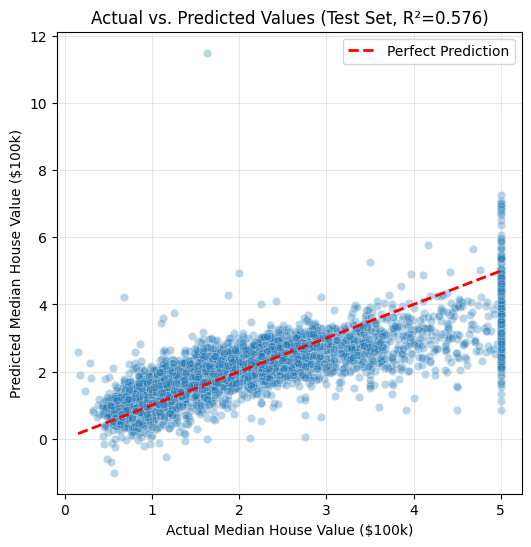

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.3, ax=ax)
ax.plot(
	[min(y_test), max(y_test)],
	[min(y_test), max(y_test)],
	"--r",
	lw=2,
	label="Perfect Prediction",
)
ax.set_xlabel("Actual Median House Value ($100k)")
ax.set_ylabel("Predicted Median House Value ($100k)")
ax.set_title(f"Actual vs. Predicted Values (Test Set, R²={r2_test:.3f})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

**Reading the Output (Typical Result for Linear Regression on California Housing):**

You'll likely see something like:

  * Training R²: \~0.61
  * Test R²: \~0.59
  * MSE values around 0.52-0.56 (since house values are in $100k units, sqrt(MSE) \~ $72k error per house—contextualize this against mean house value \~ $200k).

**Interpretation:**

  * The model explains about 59-61% of the variance in house prices. This isn't terrible, but not great either—intuitively, it captures broad trends (e.g., higher income areas have pricier homes) but misses nuances like non-linear effects (e.g., very old houses might be cheaper, but historic ones pricier).
  * The training and test scores are very close. This suggests the simple linear model is **not overfitting** (it doesn't have high variance)—it's not complex enough to memorize noise.
  * However, the overall low R² suggests the model might be **underfitting** (it has high bias). The true relationship between the features and house prices is likely more complex than a simple linear one—perhaps quadratic (e.g., income's effect plateaus) or interactive (e.g., location near ocean boosts value more in dense areas). This points towards needing a more flexible model (like a Decision Tree, Random Forest, or adding polynomial features via `PolynomialFeatures`).

  *Pedagogical Note:* Think of underfitting as using a straight ruler to draw a curvy road map—it's approximate but misses details. Overfitting is tracing every bump exactly but failing on a new road. The split helps diagnose this.

This workflow—**Split -> Fit -> Predict -> Evaluate (on Test)**—is the absolute bedrock of supervised machine learning practice. It directly addresses the Bias-Variance Trade-off by giving us an estimate of how well our model generalizes to unseen data. As you experiment, try swapping in other models (e.g., `DecisionTreeRegressor()`) and observe how metrics change— that's where the learning deepens!

### Module 1, Phase 3: Applied Practicum - Diagnosing Bias and Variance

#### Dataset: California Housing Prices

For this practicum, we'll use the California Housing dataset. It's a regression task where the goal is to predict the median house value for California districts, based on features derived from the 1990 census data. It's a standard, real-world dataset available directly in `scikit-learn`.


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Load the dataset
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target  # Median house value in $100,000s

# Display basic info
print("Dataset Info:")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Dataset Info:
Features shape: (20640, 8)
Target shape: (20640,)


In [ ]:
print("\nFeatures:")
print(X.info())


Features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB
None


In [ ]:
print("\nTarget Description:")
print(housing.DESCR)  # Read the description for context


Target Description:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census,

In [17]:
# Use a standard 80/20 split with a fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42
)

print(f"Train shape X: {X_train.shape}, y: {y_train.shape}")
print(f"Test shape  X: {X_test.shape}, y: {y_test.shape}")

Train shape X: (16512, 8), y: (16512,)
Test shape  X: (4128, 8), y: (4128,)


#### Tasks

**The Goal:** To explore how model complexity affects performance on the training and test sets, and to visually identify underfitting and overfitting. We will use a `DecisionTreeRegressor` and vary its `max_depth` as a proxy for model complexity.

**Task 1: Model Fitting and Error Calculation**

1.  Import `DecisionTreeRegressor` from `sklearn.tree` and `mean_squared_error` from `sklearn.metrics`.
2.  Create two empty lists, `train_errors` and `test_errors`.
3.  Define a range of `max_depth` values to test, for example, from 1 to 20 (`depths = range(1, 21)`).
4.  Loop through each `depth` in your `depths` range:
      * Instantiate a `DecisionTreeRegressor` with `max_depth=depth` and `random_state=42`.
      * Fit the model on the **training data** (`X_train`, `y_train`).
      * Make predictions on *both* the **training data** and the **test data**.
      * Calculate the **Mean Squared Error (MSE)** for both the training predictions (compared to `y_train`) and the test predictions (compared to `y_test`).
      * Append the calculated training MSE to `train_errors` and the test MSE to `test_errors`.
5.  **Deliverable:** A code cell that performs this loop and populates the `train_errors` and `test_errors` lists.


### Decision Tree Regressor

A Decision Tree Regressor learns a hierarchical set of rules to partition the feature space into regions and predict the target value based on the average of training samples in each region.

#### Tree Structure and Prediction

Unlike Linear Regression, which assumes a global linear relationship, a Decision Tree makes **local, piecewise constant predictions**. The tree recursively splits the data based on feature thresholds to create rectangular regions in the feature space.

For a given input $\mathbf{x}$, the prediction is:

$$\hat{y} = \sum_{m=1}^{M} c_m \cdot \mathbb{1}(\mathbf{x} \in R_m)$$

Where:
- $M$ is the number of terminal nodes (leaves) in the tree
- $R_m$ is the $m$-th rectangular region defined by the tree's splits
- $c_m$ is the predicted constant value for region $R_m$ (typically the mean of training targets in that region)
- $\mathbb{1}(\mathbf{x} \in R_m)$ is an indicator function: 1 if $\mathbf{x}$ falls in region $R_m$, 0 otherwise

#### Growing the Tree: Recursive Binary Splitting

The tree is built **top-down** by recursively partitioning the data. At each node, the algorithm searches over all features $j$ and all possible split points $s$ to find the pair $(j, s)$ that minimizes the **sum of squared errors (SSE)** in the resulting child nodes:

$$\min_{j, s} \left[ \sum_{x_i \in R_1(j,s)} (y_i - c_1)^2 + \sum_{x_i \in R_2(j,s)} (y_i - c_2)^2 \right]$$

Where:
- $R_1(j, s) = \{x \mid x_j \leq s\}$ is the left child region (feature $j$ is less than or equal to threshold $s$)
- $R_2(j, s) = \{x \mid x_j > s\}$ is the right child region (feature $j$ is greater than threshold $s$)
- $c_1 = \text{mean}(y_i \mid x_i \in R_1)$ is the average target value in the left child
- $c_2 = \text{mean}(y_i \mid x_i \in R_2)$ is the average target value in the right child

This process continues recursively until a stopping criterion is met (e.g., `max_depth` is reached, minimum samples per leaf, or no improvement in error).

#### Key Characteristics

**Advantages:**
- Can capture **non-linear relationships** and **interactions** between features automatically
- No assumptions about the functional form of $f(X)$
- Interpretable: the tree structure shows the decision rules

**Disadvantages:**
- **High variance**: small changes in training data can lead to very different trees (prone to overfitting)
- Piecewise constant predictions can be less smooth than parametric models
- Can create overly complex trees that memorize noise if not properly regularized

#### Controlling Complexity

The hyperparameter `max_depth` limits how deep the tree can grow, directly controlling the bias-variance trade-off:
- **Small `max_depth`** (e.g., 1-3): High bias (underfitting), low variance — the tree can't capture complex patterns
- **Large `max_depth`** (e.g., 15-20 or unlimited): Low bias, high variance (overfitting) — the tree memorizes training data, including noise
- **Optimal `max_depth`**: Balances bias and variance for best generalization to test data

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor

train_errors = []
test_errors = []

for depth in np.arange(1, 21, 1):
	tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
	tree.fit(X_train, y_train)

	# Make predictions on both training and test sets
	y_pred_train = tree.predict(X_train)
	y_pred_test = tree.predict(X_test)

	# Calculate MSE for both sets
	train_mse = mean_squared_error(y_train, y_pred_train)
	test_mse = mean_squared_error(y_test, y_pred_test)

	train_errors.append(train_mse)
	test_errors.append(test_mse)


**Task 2: Plotting the Complexity Curve**

1.  Using `matplotlib.pyplot`, create a plot:
      * The x-axis should be `max_depth` (your `depths` range).
      * Plot `train_errors` against `depths` using one line (e.g., blue).
      * Plot `test_errors` against `depths` using another line (e.g., red).
      * Add clear labels for the x-axis ("Max Depth of Decision Tree"), y-axis ("Mean Squared Error"), and a title ("Training vs. Test Error (Bias-Variance Trade-off)").
      * Include a legend to distinguish the training error curve from the test error curve.
      * Optionally, set the y-axis to a logarithmic scale (`plt.yscale('log')`) if the errors vary widely, which can make the trend easier to see.
2.  **Deliverable:** A code cell that generates and displays this plot.

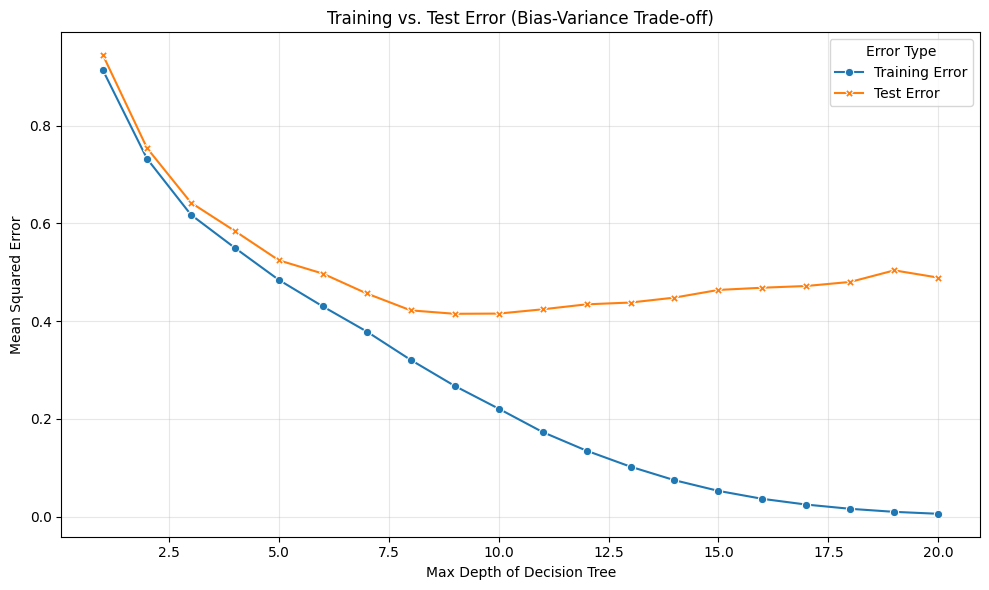

In [ ]:
# Create a DataFrame for the error data
error_df = pd.DataFrame({
	"max_depth": list(range(1, 21)),
	"train_error": train_errors,
	"test_error": test_errors,
})

# Melt the DataFrame to long format for seaborn
error_df_long = error_df.melt(
	id_vars=["max_depth"],
	value_vars=["train_error", "test_error"],
	var_name="error_type",
	value_name="mse",
)

# Rename error types for better legend labels
error_df_long["error_type"] = error_df_long["error_type"].map({
	"train_error": "Training Error",
	"test_error": "Test Error",
})

# Create the plot using seaborn with OOP approach
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
	data=error_df_long,
	x="max_depth",
	y="mse",
	hue="error_type",
	style="error_type",
	markers=True,
	dashes=False,
	ax=ax,
)

ax.set(
	xlabel="Max Depth of Decision Tree",
	ylabel="Mean Squared Error",
	title="Training vs. Test Error (Bias-Variance Trade-off)",
)

ax.legend(title="Error Type")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



**Task 3: Interpretation (The Core of the Practicum)**

1.  Examine the plot you created in Task 2.
2.  Identify the region on the plot corresponding to **high bias (underfitting)**. Describe what happens to both training and test errors in this region and *why* (link it to model complexity).
3.  Identify the region on the plot corresponding to **high variance (overfitting)**. Describe what happens to both training and test errors in this region and *why* (link it to model complexity).
4.  Identify the approximate "sweet spot" – the `max_depth` value (or range of values) where the **test error** is minimized, representing the best trade-off between bias and variance for this model and data.
5.  **Deliverable:** A markdown cell containing your written interpretation, clearly addressing points 2, 3, and 4. Relate the observed error patterns directly back to the concepts of underfitting, overfitting, and the bias-variance trade-off.

### I'm doubtful about the sweet spot, it might be either 5 or 8, I'll try both then.

#### Option 1: Attempt with 5

In [34]:
from sklearn.tree import DecisionTreeRegressor

dtr_5 = DecisionTreeRegressor(max_depth=5, random_state=42)

dtr_5.fit(X_train, y_train)
y_pred_5 = dtr_5.predict(X_test)

r2_score_5 = dtr_5.score(X_test, y_test)
print(f"Max Depth = 5, R2 Score: {r2_score_5:.4f}")
print(f"Max Depth = 5, Test MSE: {mean_squared_error(y_test, y_pred_5):.4f}")

Max Depth = 5, R2 Score: 0.5997
Max Depth = 5, Test MSE: 0.5245


#### Option 2: Attempt with 8

In [35]:
from sklearn.tree import DecisionTreeRegressor

dtr_8 = DecisionTreeRegressor(
	max_depth=8,
	random_state=42,
)

dtr_8.fit(X_train, y_train)
y_pred_8 = dtr_8.predict(X_test)


r2_score_8 = dtr_8.score(X_test, y_test)

print(f"Max Depth = 8, R2 Score: {r2_score_8:.4f}")
print(f"Max Depth = 8, Test MSE: {mean_squared_error(y_test, y_pred_8):.4f}")

Max Depth = 8, R2 Score: 0.6779
Max Depth = 8, Test MSE: 0.4220


Well, neither of those options look good to me... I guess I should fine tune them even further